In [1]:
import numpy as np
import sympy as sp

import matplotlib as mpl
from matplotlib import pyplot as plt
from scipy.integrate import quad

mpl.rc('text', usetex = True)

from ofex.classical_algorithms.funcapprox import uniform_inner_product, FunctionBasis, plot_functions, FourierBasis, \
    FirstChebyshevBasis

# 1. Function Approximation

Consider a function space equipped with an inner product $\braket{f,g}\in\mathbb{C}$ and the corresponding norm $\|f\|^2 = \braket{f, f}$, where the inner product satisfies:
  - **Linearity**: $\braket{f,ag_1+bg_2}=a\braket{f,g_1}+b\braket{f,g_2}\quad \forall~a, b \in \mathbb{C}$
  - **Symmetry**: $\braket{f, g} = \braket{g, f}^*$
  - **Positivity**: $\braket{f, f} \ge 0$, and $\braket{f, f} = 0$ iff $f=0$.

Given a finite set of basis functions $\mathcal{V}_n=\{v_k:k=1,\cdots, n\}$, we aim to solve the approximation problem such that a target function $f$ is approximated by the linear combination of the basis functions:
$$
    \min_{\vec{c}\in \mathbb{C}^n}\|f - g\|\quad \mathrm{s.t.}\quad g = \sum_{k=1}^n c_k v_k.
$$
Using the properties of inner products, it can be shown that the approximation problem is solvable by the following linear equation:
$$
    \mathbf{S}\vec{c}^{\star} = \vec{\mu} \quad \mathrm{where} \quad [\mathbf{S}]_{kl} = \braket{v_k,v_l}~\mathrm{and}~[\vec{\mu}]_k = \braket{v_k, f}.
$$
Furthermore, the resulting error is given as
$$
    \min_{\vec{c}}\|f-g\| = (\|f\|^2 - \vec{\mu}^\dagger \vec{c}^{\star})^{1/2}.
$$

Especially, when the $n$ basis functions are finitely chosen from the complete orthogonal set (such as Fourier and (normalized) Chebyshev poly series in the next section):
$$
    \mathcal{V}_n \subseteq \mathcal{V}_{\infty}\quad \braket{v_k, v_l} = \delta_{kl} \quad \forall v_k, v_l \in \mathcal{V}_{\infty}
$$
we have the error bound of
$$
    \|f-g\| = \left(\sum_{k=n+1}^{\infty} |\mu_k|^2 \right)^{1/2},
$$
because the orthonormality makes $\mathbf{S}=\mathbb{I}$ and $\vec{c}^{\star}=\vec{\mu}$, and the completeness ensures
$$
    f = \sum_{k=1}^{\infty} c^{\star}_k v_k
$$

Furthermore, the max norm residual,
$$
    \|f-g\|_{\infty} := \max_{x\in\mathcal{D}}|f(x)-g(x)| = \max_{x\in\mathcal{D}}\left| \sum_{k=n+1}^{\infty} \mu_k v_k(x)\right| \le \sum_{k=n+1}^{\infty} |\mu_k| \|v_k\|_\infty
$$
Note that the max norm is **not** derived from the function inner product since it lacks of linearity. Also, the orthonormality doesn't ensure the finite max norm.
$$
    \|v_k\|=1 \nRightarrow \|v_k\|_\infty < \infty
$$

## Example

Such definition and function approximation are included in `ofex.classical_algorithms.FunctionBasis`. The following example code includes a function approximation with a custom definition of function inner product and basis function:
$$
    \braket{f,g}_{\mathrm{u}} =\frac{1}{2}\int_{-1}^{1}f^*(x)g(x)dx,\quad \mathcal{V} = \{1, x^2, x^3, \sin \pi x\},
$$
and the target function is
$$
    f(x) = e^x
$$

In [2]:
# Custom function inner product performs uniform integral
def custom_inner_product(v1:sp.Expr, v2:sp.Expr) -> complex:
    prod = sp.simplify((v1.conjugate() * v2))
    syms = prod.free_symbols
    if len(syms) == 0:
        return complex(prod)
    elif len(syms) > 1:
        raise ValueError(f"There are redundant symbols {prod}, {syms}")
    x = list(syms)[0]
    integral = sp.integrate(prod, (x, -1, 1))
    return complex(integral / 2)

# Equivalently, you can use
# custom_inner_product = uniform_inner_product(x_max=1.0, numerical_integ=True)

# Custom basis functions
x = sp.Symbol('x')
custom_functions = [1, x**2, x**3, sp.sin(sp.pi * x)]

# Basis functions equipped with the inner product
custom_function_basis = FunctionBasis(custom_functions, custom_inner_product)

# overlap matrix S
print("Overlap matrix S:")
print(custom_function_basis.overlap_matrix)

Overlap matrix S:
[[1.        +0.j 0.33333333+0.j 0.        +0.j 0.        +0.j]
 [0.33333333+0.j 0.2       +0.j 0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.14285714+0.j 0.12480068+0.j]
 [0.        +0.j 0.        +0.j 0.12480068+0.j 0.5       +0.j]]


Optimal function: 1.25304303128619*x**3 + 0.536721525971059*x**2 + 0.366564939695582*sin(pi*x) + 0.996294018320115
Residual error norm: 0.024320712684105256


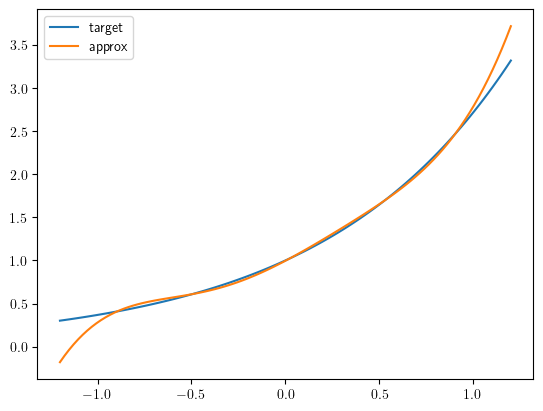

In [3]:
# Target function
f = sp.exp(x)

# Perform the optimization
opt_g, coeffs, diff_norm = custom_function_basis.l2_minimization(f)

print(f"Optimal function: {opt_g}")
print(f"Residual error norm: {diff_norm}")
plot_functions({"target": f, "approx": opt_g}, x, x_points=np.linspace(-1.2, 1.2, 100))



# 2. Function Approximation Examples

## 2-1. Fourier Series

Consider the following basis functions, and the inner product of
$$
    \mathcal{V}^{(\mathrm{f})}_n:=\{v_k^{(\mathrm{f})}(x)=e^{ik\pi x}: k=-n,\cdots,n\}\quad\braket{f,g}_{\mathrm{u}} =\frac{1}{2}\int_{-1}^{1}f^*(x)g(x)dx,
$$
where its implementation is given in `ofex.classical_algorithms.uniform_inner_product` with `x_max=1.0`.

We have a nice orthogonality of these basis and inner product:
$$
    \braket{v_k^{(\mathrm{f})},v_l^{(\mathrm{f})}}_{\mathrm{u}}=\delta_{kl},
$$
which makes $\mathbf{S}=\mathbb{I}$ and $\vec{c}^{\star} = \vec{\mu}$. Therefore, the famous Fourier series formula is derived:
$$
    c_k = \braket{v_k^{(\mathrm{f})}, f} = \frac{1}{2}\int_{-1}^{1} f(x) e^{-ik\pi x} dx.
$$

The following example shows the Fourier series approximation of $f(x)=e^{-4x^2}$ with the basis function of $\mathcal{V}_n^{(\mathrm{f})}$ with $n=4$.

In [4]:
fourier_functions = [sp.exp(1j * np.pi * x * k) for k in range(-4, 5)]
fourier_function_basis = FunctionBasis(fourier_functions, uniform_inner_product(x_max=1.0, numerical_integ=True))
print("Overlap matrix S (Fourier basis):")
with np.printoptions(precision=1, linewidth=300):
    print(fourier_function_basis.overlap_matrix)
print(f"Is close to identity matrix?: {np.allclose(fourier_function_basis.overlap_matrix, np.eye(fourier_function_basis.n_basis))}")


Overlap matrix S (Fourier basis):
[[ 1.0e+00+0.j -9.0e-15+0.j  3.9e-15+0.j -3.2e-15+0.j  2.2e-15+0.j -1.6e-15+0.j  1.8e-15+0.j -1.5e-15+0.j  1.9e-15+0.j]
 [-9.0e-15+0.j  1.0e+00+0.j  1.2e-15+0.j  5.0e-16+0.j  2.1e-17+0.j -3.2e-16+0.j -1.8e-16+0.j -1.3e-16+0.j -1.5e-15+0.j]
 [ 3.9e-15+0.j  1.2e-15+0.j  1.0e+00+0.j -2.1e-15+0.j  4.7e-16+0.j  3.2e-17+0.j  4.7e-16+0.j -1.8e-16+0.j  1.8e-15+0.j]
 [-3.2e-15+0.j  5.0e-16+0.j -2.1e-15+0.j  1.0e+00+0.j  9.9e-16+0.j -9.8e-16+0.j  3.2e-17+0.j -3.2e-16+0.j -1.6e-15+0.j]
 [ 2.2e-15+0.j  2.1e-17+0.j  4.7e-16+0.j  9.9e-16+0.j  1.0e+00+0.j  9.9e-16+0.j  4.7e-16+0.j  2.1e-17+0.j  2.2e-15+0.j]
 [-1.6e-15+0.j -3.2e-16+0.j  3.2e-17+0.j -9.8e-16+0.j  9.9e-16+0.j  1.0e+00+0.j -2.1e-15+0.j  5.0e-16+0.j -3.2e-15+0.j]
 [ 1.8e-15+0.j -1.8e-16+0.j  4.7e-16+0.j  3.2e-17+0.j  4.7e-16+0.j -2.1e-15+0.j  1.0e+00+0.j  1.2e-15+0.j  3.9e-15+0.j]
 [-1.5e-15+0.j -1.3e-16+0.j -1.8e-16+0.j -3.2e-16+0.j  2.1e-17+0.j  5.0e-16+0.j  1.2e-15+0.j  1.0e+00+0.j -9.0e-15+0.j]
 [ 1.9

Optimal function: 0.241001633094851*exp(3.14159265358979*I*x) + 0.0361321000219835*exp(6.28318530717959*I*x) + 0.00273791646612104*exp(9.42477796076938*I*x) - 0.00068194845861622*exp(12.5663706143592*I*x) + 0.44104069538121 - 0.00068194845861622*exp(-12.5663706143592*I*x) + 0.00273791646612104*exp(-9.42477796076938*I*x) + 0.0361321000219835*exp(-6.28318530717959*I*x) + 0.241001633094851*exp(-3.14159265358979*I*x)
Residual error norm: 0.0011127648658562947


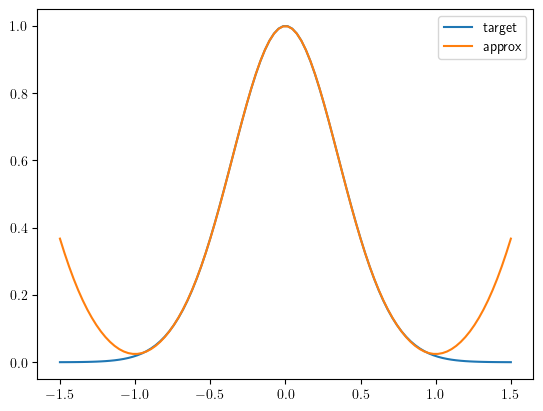

In [5]:
f = sp.exp(-4 * x**2)
opt_g, coeffs, diff_norm = fourier_function_basis.l2_minimization(f)

print(f"Optimal function: {opt_g}")
print(f"Residual error norm: {diff_norm}")
plot_functions({"target": f, "approx": opt_g}, x, x_points=np.linspace(-1.5, 1.5, 100))

Since our inner product is defined only over the interval $[−1,1]$, the approximation deviates from the target function for $|x|>1$. Additionally, because the basis function is periodic, the resulting approximating function is also periodic.

We also can use `FourierBasis` class doing the same thing but reduced computational overhead when calculating the overlap matrix leveraged by the orthogonality.

Optimal function: 0.241001633094851*exp(3.14159265358979*I*x) + 0.0361321000219832*exp(6.28318530717959*I*x) + 0.00273791646612113*exp(9.42477796076938*I*x) - 0.000681948458616215*exp(12.5663706143592*I*x) + 0.441040695381211 - 0.000681948458616215*exp(-12.5663706143592*I*x) + 0.00273791646612113*exp(-9.42477796076938*I*x) + 0.0361321000219832*exp(-6.28318530717959*I*x) + 0.241001633094851*exp(-3.14159265358979*I*x)
Residual error norm: 0.0011127648657565231


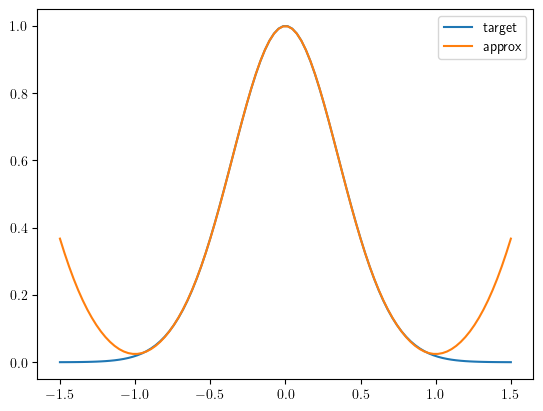

In [6]:
fourier_function_basis = FourierBasis(4, numerical_integ=True)
opt_g, coeffs, diff_norm = fourier_function_basis.l2_minimization(f)

print(f"Optimal function: {opt_g}")
print(f"Residual error norm: {diff_norm}")
plot_functions({"target": f, "approx": opt_g}, x, x_points=np.linspace(-1.5, 1.5, 100))

## 2-2. Fourier Series with Higher-Order Derivatives

Consider the following basis:
$$
    \mathcal{V}_{n,d}^{(\mathrm{f})} = \bigcup_{l=0}^{d}\{x^le^{ik\pi x}:k=-n,\cdots,n\}.
$$
Each basis function has form of a product of monomial and complex exponentials. Also, $d=0$ reduces to the regular Fourier basis.
Note that the basis functions are no longer orthogonal.

In the following example, we observe how $\mathcal{V}_{n,d}^{(\mathrm{f})}$ for $d=0,\cdots,3$ approximates the following target function:
$$
    f(x) = x e^{-4x^2}
$$

In [7]:
min_harmonics = 1
max_harmonics = 10
max_deriv = 3

f = x * sp.exp(-4 * x**2)

deriv_fourier = FourierBasis(max_harmonics, deriv_order=max_deriv, numerical_integ=True)
opt_result = dict()
for d in range(max_deriv + 1):
    opt_result[d] = deriv_fourier.gradual_l2_minimization(f, n_min=min_harmonics, n_max=max_harmonics, max_deriv_order=d)

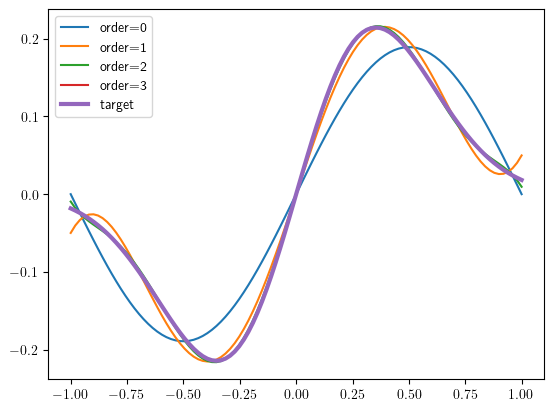

In [8]:
sample_n = 2
func_list = {f"order={d}": opt_result[d][sample_n][0] for d in range(max_deriv + 1)}
func_list["target"] = f
plot_functions(func_list, x, x_points=np.linspace(-1.0, 1.0, 100), plot_options={"target": {"linewidth": 3.0}})

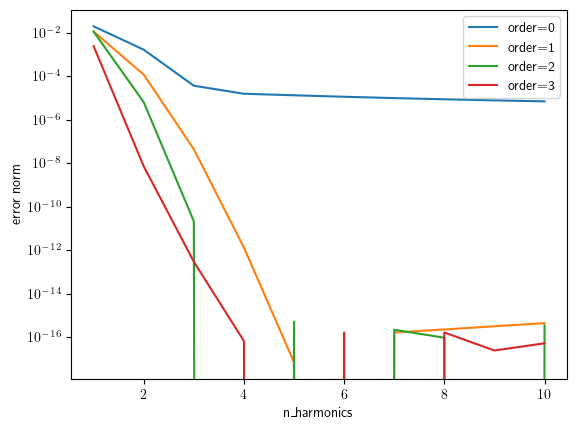

In [9]:
n_list = list(range(min_harmonics, max_harmonics+1))
for d in range(max_deriv + 1):
    diff_norm = np.array([opt_result[d][n][2] for n in n_list])
    assert np.allclose(diff_norm.imag, 0.0)
    diff_norm = diff_norm.real
    plt.plot(n_list, diff_norm, label=f"order={d}")
plt.legend()
plt.xlabel("n_harmonics")
plt.ylabel("error norm")
plt.yscale("log")

The Fourier series with higher order derivatives makes the error norm converges much faster.

## 2-3. Chebyshev Series

Consider the following Chebyshev polynomial basis and inner product weighted by $(1-x^2)^{-1/2}$:
$$
    \mathcal{V}_n^{(\mathrm{c})} = \{T_k(x):k=0,\cdots,n\}\quad\braket{f,g}_{\cup}:=\int_{-1}^{1}\frac{f^*(x)g(x)}{\sqrt{1-x^2}}dx.
$$

Then we have the following orthogonality:
$$
    \braket{T_{k}, T_{l}}=\begin{cases}
        0 \quad &k\neq l\\
        \pi \quad &k=l=0\\
        \pi/2 \quad &k=l\neq 0
    \end{cases}
$$

The following example approximates the following target function
$$
    f(x) = xe^{-4x^2}
$$

In [10]:
n_cheby = 10
cheby = FirstChebyshevBasis(n_cheby, numerical_integ=True, debug=True)

f = x * sp.exp(-4 * x**2)

opt_results_cheby = cheby.gradual_l2_minimization(f)

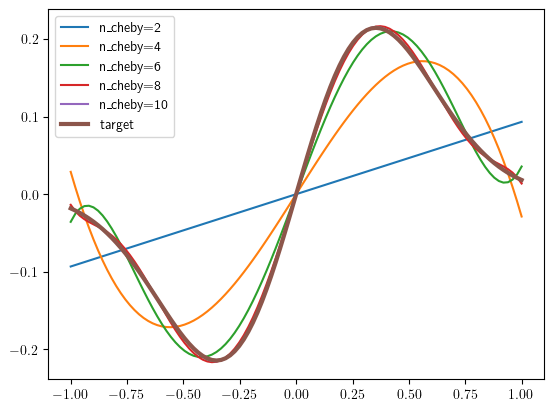

In [11]:
select_n = [2,4,6,8,10]
func_list = {f"n_cheby={n}": opt_results_cheby[n][0] for n in select_n}
func_list["target"] = f
plot_functions(func_list, x, x_points=np.linspace(-1.0, 1.0, 100), plot_options={"target": {"linewidth": 3.0}})

Text(0, 0.5, 'error norm')

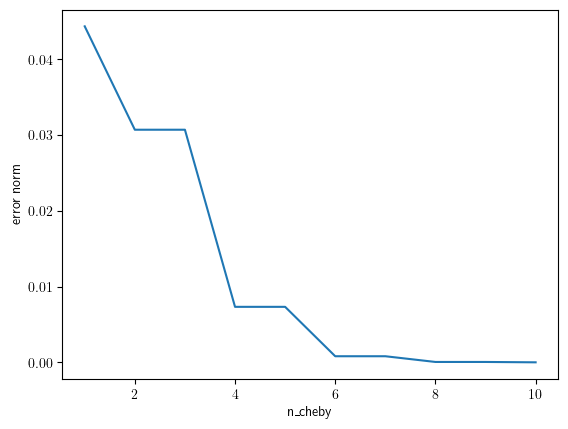

In [12]:
n_list = list(range(1, n_cheby+1))
diff_norm = np.array([opt_results_cheby[n][2] for n in n_list])
assert np.allclose(diff_norm.imag, 0.0)
diff_norm = diff_norm.real
plt.plot(n_list, diff_norm)
plt.xlabel("n_cheby")
plt.ylabel("error norm")

# 3. Regularized Approximation

## 3-1. L1-Regularization
Let's assume that approximating a function $f$ with the basis of $\{v_k\}$ and their inner product of $\braket{\cdot, \cdot}$, produces an exact optimal coefficients $\vec{c}$. After the optimization, if only the erroneous accesses to $v_k$, $\tilde{v}_k$, are possible, we have the following error bound by triangular inequality:
$$
\begin{split}
    \|\tilde{g}(x;\vec{c}) - f(x)\| \le& \|g(x;\vec{c}) - f(x)\| + \|\tilde{g}(x;\vec{c}) - g(x;\vec{c})\|\\
    \le& \left[ \|f(x)\|^2 +\vec{c}^{\dagger}\mathbf{S}\vec{c} - (\vec{c}^{\dagger}\vec{\mu}+\vec{\mu}^{\dagger}\vec{c}) \right]^{1/2} + \sum_k |c_k| \|\epsilon_k(x)\|
\end{split}
$$
where $\epsilon_k(x) = \tilde{v}_k(x) - v_k(x)$.
We aim to minimize the error bound:
$$
    \min_{\vec{c}}\left[\|f\|^2 + \vec{c}^{\dagger}\mathbf{S}\vec{c} - (\vec{c}^{\dagger}\vec{\mu}+\vec{\mu}^{\dagger}\vec{c})\right]^{1/2} + \sum_k |c_k| \|\epsilon_k\|.
$$
After performing the Lagrangian multiplier method with the Wirtinger calculus (i.e. treating $c_k$ and $c_k^*$ as independent variables), we have:
$$
    \mathbf{S}\vec{c}^{\mathrm{(opt)}} = \vec{\mu} - \vec{\delta}(\vec{c}^{\mathrm{(opt)}}),
$$
where
$$
    [\vec{\delta}(\vec{c})]_k := e^{i \mathrm{arg}(c_k)}\left[\|f\|^2 + \vec{c}^{\dagger}\mathbf{S}\vec{c} - (\vec{c}^{\dagger}\vec{\mu}+\vec{\mu}^{\dagger}\vec{c})\right]^{1/2}\|\epsilon\|_k.
$$

`FunctionBasis.l2_minimization_regularized` method with `order=1` iteratively find such optimal points by updating new $\vec{c}$ with the previously found $\vec{\delta}$.


## 3-2. L2-Regularization

We have another error bound by parallelogram law:
$$
\begin{split}
    \|\tilde{g}(x;\vec{c}) - f(x)\|\le& \left[\|g(x;\vec{c}) - f(x)\|^2 + \|\tilde{g}(x;\vec{c}) - g(x;\vec{c})\|^2\right]^{1/2}\\
    \le& \left[\|f(x)\|^2 +\vec{c}^{\dagger}\mathbf{S}\vec{c} - (\vec{c}^{\dagger}\vec{\mu}+\vec{\mu}^{\dagger}\vec{c}) + \vec{c}^{\dagger}\mathbf{E}\vec{c}\right]^{1/2},
\end{split}
$$
where $\mathbf{E}=\vec{\epsilon}\vec{\epsilon}^{\mathrm{T}}$.
This has a simpler solution, which is
$$
    (\mathbf{S}+\mathbf{E})\vec{c}=\vec{\mu}.
$$


We demonstrate an example of approximating $f(x)=x$ for $x\in[-1,1]$ with Fourier basis.
And then, we combine the resulting coefficients and the erroneous basis functions with gaussian noises.

In [26]:
np.random.seed(42)

def gaussian_noise_function(N: int, epsilon: float,):
    coeffs_real = np.random.normal(0, 1, 2 * N + 1)  # Real parts
    coeffs_imag = np.random.normal(0, 1, 2 * N + 1)  # Imaginary parts
    g = sum(
        (coeffs_real[n + N] + sp.I * coeffs_imag[n + N]) * sp.exp(sp.I * n * x)
        for n in range(-N, N + 1)
    )
    # Compute the L^2 norm of g(x)
    g_lambdified = sp.lambdify(x, sp.Abs(g)**2, 'numpy')
    norm_squared = quad(g_lambdified, -1, 1)[0]

    # Scale g(x) to satisfy ||g|| < epsilon
    # rand_epsilon = np.random.rand() * epsilon
    scaling_factor = sp.sqrt(epsilon**2 / norm_squared)
    g_scaled = g * scaling_factor
    return g_scaled


f = x
n_harmonics = 10
epsilon = 0.6

fb = FourierBasis(n_harmonics, numerical_integ=True, sym_x=x)
l2_min_coeff = fb.l2_minimization(f)[1]
# l2_min_reg1_coeff = fb.l2_minimization_regularized(f, order=1, reg_coeff=epsilon)[1]
l2_min_reg2_coeff = fb.l2_minimization_regularized(f, order=2, reg_coeff=epsilon)[1]

err_funcs = [gaussian_noise_function(20, epsilon) for _ in range(fb.n_basis)]
err_basis = [bf + ef for bf, ef in zip(fb.basis, err_funcs)]

l2_min = sp.Add(*(c * bf for c, bf in zip(l2_min_coeff, err_basis)))
# l2_min_reg1 = sp.Add(*(c * bf for c, bf in zip(l2_min_reg1_coeff, err_basis)))
l2_min_reg2 = sp.Add(*(c * bf for c, bf in zip(l2_min_reg2_coeff, err_basis)))


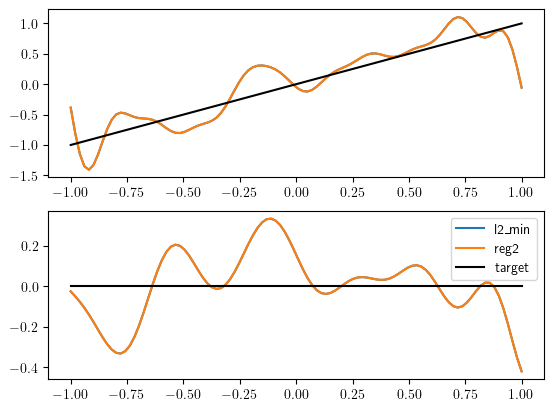

In [27]:
plot_functions({"l2_min": l2_min,
                "reg2": l2_min_reg2,
                "target": f},
               x, plot_options={"target": {"color": "black"}})

In [28]:
l2_min - l2_min_reg2

1.93057935229677e-17*I*(0.0444958273418273*(0.2029230208513 - 0.393338812327361*I)*exp(20*I*x) + 0.0444958273418273*(0.632931817755511 + 0.368673308872901*I)*exp(19*I*x) + 0.0444958273418273*(-0.552223044280971 - 0.816935670987236*I)*exp(18*I*x) + 0.0444958273418273*(0.471415556386404 + 1.20650896650836*I)*exp(17*I*x) + 0.0444958273418273*(-0.832355573104229 + 0.146713686433323*I)*exp(16*I*x) + 0.0444958273418273*(-0.570746293749476 - 0.167118080316854*I)*exp(15*I*x) + 0.0444958273418273*(1.42050424798985 + 0.648709887589643*I)*exp(14*I*x) + 0.0444958273418273*(1.18901653110755 + 1.38215899103753*I)*exp(13*I*x) + 0.0444958273418273*(-0.637387127306518 + 1.16929559044567*I)*exp(12*I*x) + 0.0444958273418273*(-0.555477119160255 + 1.06667468958915*I)*exp(11*I*x) + 0.0444958273418273*(-0.623140526424764 + 0.507274031107298*I)*exp(10*I*x) + 0.0444958273418273*(-0.530996955001818 + 0.820482181197364*I)*exp(9*I*x) + 0.0444958273418273*(-0.637739984251316 + 1.10870358058291*I)*exp(8*I*x) + 0.04